# Exploring SAE Neuron Explanations

Analysis of explanation quality for sparse autoencoder neurons trained on **Qwen 2.5-3B-Instruct**, explained by DeepSeek V3.2.

**Data structure:**
- 1,132 neurons across 5 layers (0, 8, 17, 26, 35)
- Base JSONs: neuron explanations + high/low activation examples
- Simulation JSONs: predictions of what text each neuron activates on
- Unified score JSONs: multi-signal scoring (concept, meaning, overlap, location, combined)
- Similarity JSONs: cosine similarity + character-level alignment (39 neurons only)

In [ ]:
# import json, os, glob, re
# import pandas as pd
# import numpy as np
# import matplotlib
# import matplotlib.pyplot as plt
# matplotlib.rcParams['figure.dpi'] = 120

# EXPL_DIR = 'explanations'

## 1. Load all unified scores into a flat DataFrame

In [2]:
rows = []
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    with open(path) as f:
        data = json.load(f)
    nid = data['neuron_id']
    layer = int(nid.split('_')[0])
    neuron = int(nid.split('_')[1])
    for res in data['results']:
        for pair in res['pairs']:
            rows.append({
                'neuron_id': nid,
                'layer': layer,
                'neuron': neuron,
                'example_idx': res['example_idx'],
                'normalized_activation': res['normalized_activation'],
                'prediction_rank': pair['prediction_rank'],
                'concept_score': pair['concept_score'],
                'meaning_score': pair['meaning_score'],
                'overlap_fraction': pair['overlap_fraction'],
                'location_score': pair['location_score'],
                'combined_score': pair['combined_score'],
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} score rows across {df['neuron_id'].nunique()} neurons")
df.head()

Loaded 12811 score rows across 854 neurons


,neuron_id,layer,neuron,example_idx,normalized_activation,prediction_rank,concept_score,meaning_score,overlap_fraction,location_score,combined_score
0,0_10033,0,10033,1,9.701710,1,0.2027,0.5938,0.0,0.000,0.2828
1,0_10033,0,10033,1,9.701710,2,0.2467,0.5581,0.0,0.000,0.2742
2,0_10033,0,10033,1,9.701710,3,0.1868,0.2863,0.0,0.000,0.1497
3,0_10033,0,10033,2,8.889501,1,0.2126,0.4037,0.0,0.000,0.2035
4,0_10033,0,10033,2,8.889501,2,0.1597,0.4324,1.0,0.425,0.6327


## 2. Per-neuron summary: best combined score across all examples/predictions

In [3]:
# For each neuron, take the best combined_score across all (example, prediction) pairs
neuron_best = df.groupby(['neuron_id', 'layer']).agg(
    best_combined=('combined_score', 'max'),
    mean_combined=('combined_score', 'mean'),
    best_concept=('concept_score', 'max'),
    mean_concept=('concept_score', 'mean'),
    best_meaning=('meaning_score', 'max'),
    mean_meaning=('meaning_score', 'mean'),
    best_overlap=('overlap_fraction', 'max'),
    mean_overlap=('overlap_fraction', 'mean'),
    n_examples=('example_idx', 'nunique'),
).reset_index()

print(f"{len(neuron_best)} neurons with unified scores")
neuron_best.describe().round(3)

854 neurons with unified scores


,layer,best_combined,mean_combined,best_concept,mean_concept,best_meaning,mean_meaning,best_overlap,mean_overlap,n_examples
count,854.000,854.000,854.000,854.000,854.000,854.000,854.000,854.000,854.000,854.0
mean,12.552,0.748,0.286,0.355,0.193,0.792,0.452,0.912,0.153,5.0
std,11.249,0.135,0.056,0.143,0.047,0.094,0.062,0.259,0.083,0.0
min,0.000,0.235,0.141,0.162,0.106,0.454,0.275,0.000,0.000,5.0
25%,0.000,0.747,0.244,0.248,0.160,0.743,0.408,1.000,0.082,5.0
50%,8.000,0.789,0.286,0.303,0.182,0.804,0.452,1.000,0.133,5.0
75%,17.000,0.818,0.327,0.444,0.214,0.857,0.497,1.000,0.200,5.0
max,35.000,0.934,0.450,1.000,0.435,1.000,0.623,1.000,0.400,5.0


## 3. Score distributions

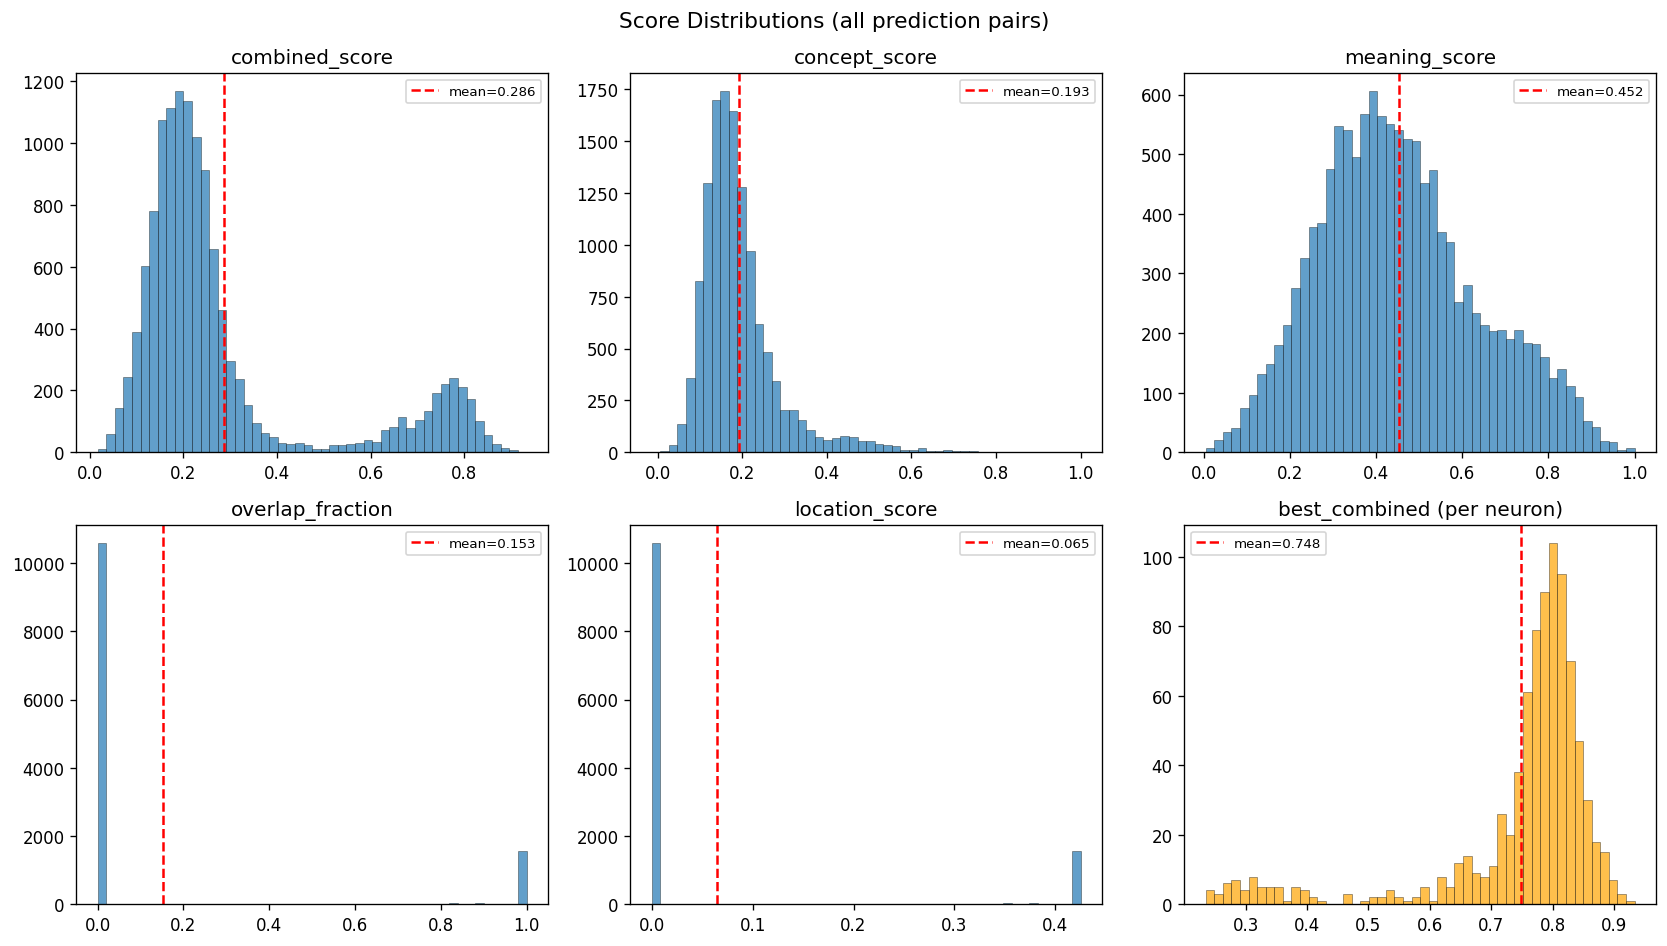

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, ['combined_score', 'concept_score', 'meaning_score',
                                'overlap_fraction', 'location_score']):
    ax.hist(df[col], bins=50, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(col)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.3f}')
    ax.legend(fontsize=8)

# Best combined per neuron
ax = axes.flat[5]
ax.hist(neuron_best['best_combined'], bins=50, alpha=0.7, edgecolor='black', linewidth=0.3, color='orange')
ax.set_title('best_combined (per neuron)')
ax.axvline(neuron_best['best_combined'].mean(), color='red', linestyle='--',
           label=f'mean={neuron_best["best_combined"].mean():.3f}')
ax.legend(fontsize=8)

fig.suptitle('Score Distributions (all prediction pairs)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Layer-wise comparison

In [5]:
layer_stats = neuron_best.groupby('layer')[['best_combined', 'mean_combined',
                                             'best_concept', 'best_meaning',
                                             'best_overlap']].agg(['mean', 'median', 'std', 'count'])
layer_stats.columns = ['_'.join(c) for c in layer_stats.columns]
layer_stats

,best_combined_mean,best_combined_median,best_combined_std,best_combined_count,mean_combined_mean,mean_combined_median,mean_combined_std,mean_combined_count,best_concept_mean,best_concept_median,best_concept_std,best_concept_count,best_meaning_mean,best_meaning_median,best_meaning_std,best_meaning_count,best_overlap_mean,best_overlap_median,best_overlap_std,best_overlap_count
layer,,,,,,,,,,,,,,,,,,,,
0,0.771474,0.8025,0.122986,233,0.296070,0.296280,0.057809,233,0.417589,0.3691,0.169286,233,0.814684,0.82380,0.088781,233,0.928400,1.0,0.232840,233
8,0.748849,0.7893,0.130734,257,0.285467,0.285587,0.056134,257,0.342237,0.2946,0.139546,257,0.795081,0.80430,0.085657,257,0.911413,1.0,0.256764,257
17,0.747457,0.7830,0.129815,178,0.284634,0.286500,0.054484,178,0.331297,0.3008,0.112311,178,0.791988,0.81175,0.097323,178,0.922384,1.0,0.240552,178
26,0.731730,0.7715,0.134837,97,0.279519,0.278587,0.053050,97,0.346051,0.3053,0.121432,97,0.772493,0.78360,0.087789,97,0.904229,1.0,0.269235,97
35,0.705465,0.7672,0.175316,89,0.270646,0.266133,0.052317,89,0.283733,0.2637,0.079674,89,0.744343,0.75710,0.113285,89,0.861780,1.0,0.338412,89


/var/folders/wk/5zgfdm_n5h1_8_3hl8wppln00000gp/T/ipykernel_8503/2047973838.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=sorted(neuron_best['layer'].unique()), patch_artist=True)
/var/folders/wk/5zgfdm_n5h1_8_3hl8wppln00000gp/T/ipykernel_8503/2047973838.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=sorted(neuron_best['layer'].unique()), patch_artist=True)
/var/folders/wk/5zgfdm_n5h1_8_3hl8wppln00000gp/T/ipykernel_8503/2047973838.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=sorted(neuron_

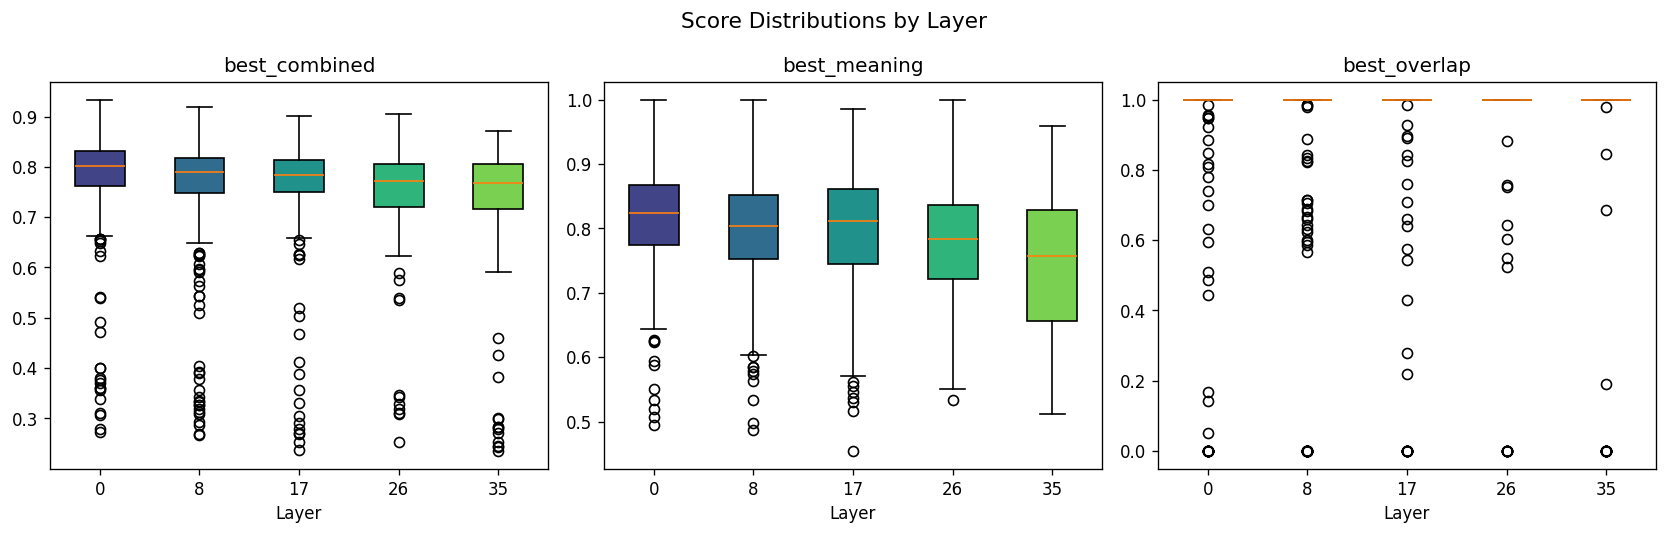

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, metric in zip(axes, ['best_combined', 'best_meaning', 'best_overlap']):
    data_by_layer = [neuron_best[neuron_best['layer'] == l][metric].values
                     for l in sorted(neuron_best['layer'].unique())]
    bp = ax.boxplot(data_by_layer, labels=sorted(neuron_best['layer'].unique()), patch_artist=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(data_by_layer)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_title(metric)
    ax.set_xlabel('Layer')

fig.suptitle('Score Distributions by Layer', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Prediction rank analysis

Does rank 1 consistently outperform rank 2 and 3?

In [7]:
rank_stats = df.groupby('prediction_rank')[['combined_score', 'meaning_score',
                                              'overlap_fraction', 'concept_score']].mean()
print("Mean scores by prediction rank:")
rank_stats.round(4)

Mean scores by prediction rank:


,combined_score,meaning_score,overlap_fraction,concept_score
prediction_rank,,,,
1,0.3757,0.5115,0.3015,0.2015
2,0.2536,0.4344,0.0953,0.1895
3,0.2286,0.4101,0.0620,0.1866


In [8]:
# How often is rank 1 the best prediction?
best_rank_per_example = df.loc[df.groupby(['neuron_id', 'example_idx'])['combined_score'].idxmax()]
rank_win_pct = best_rank_per_example['prediction_rank'].value_counts(normalize=True).sort_index()
print("How often each rank has the highest combined_score:")
print(rank_win_pct.round(3))

How often each rank has the highest combined_score:
prediction_rank
1    0.532
2    0.257
3    0.211
Name: proportion, dtype: float64


## 6. High-activation vs low-activation examples

Do predictions for high-activation examples score better than for low-activation ones?

In [9]:
df['is_high_activation'] = df['normalized_activation'] > 0

activation_comparison = df.groupby('is_high_activation')[['combined_score', 'meaning_score',
                                                            'overlap_fraction']].mean()
activation_comparison.index = ['Low (0.0)', 'High (>0)']
print("Mean scores for high vs low activation examples:")
activation_comparison.round(4)

Mean scores for high vs low activation examples:


,combined_score,meaning_score,overlap_fraction
Low (0.0),0.2916,0.4491,0.1760
High (>0),0.2825,0.4538,0.1387


## 7. Best and worst explained neurons

In [10]:
# Load explanations text for context
explanations = {}
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    with open(path) as f:
        data = json.load(f)
    explanations[data['neuron_id']] = data.get('explanation_used', '')[:200]  # first 200 chars

neuron_best['explanation_preview'] = neuron_best['neuron_id'].map(explanations)

In [11]:
print("=== TOP 10 BEST EXPLAINED NEURONS (by best_combined) ===")
top10 = neuron_best.nlargest(10, 'best_combined')[['neuron_id', 'layer', 'best_combined',
                                                     'mean_combined', 'explanation_preview']]
for _, row in top10.iterrows():
    print(f"\n{row['neuron_id']} (layer {row['layer']}) | best={row['best_combined']:.3f} mean={row['mean_combined']:.3f}")
    print(f"  {row['explanation_preview']}...")

=== TOP 10 BEST EXPLAINED NEURONS (by best_combined) ===

0_3289 (layer 0) | best=0.934 mean=0.296
  1. **Opening statement**: This neuron strongly responds to **mentions of abstract forces, factors, or effects that exert influence or cause outcomes** (such as *market forces*, *police forces*, *key f...

8_12275 (layer 8) | best=0.920 mean=0.366
  1. **Opening statement**: This neuron strongly responds to **mentions of heads of government, particularly prime ministers** (such as "Prime Minister Boris Johnson," "Prime Minister Narendra Modi," or...

8_13563 (layer 8) | best=0.913 mean=0.287
  1. **Opening statement**: This neuron strongly responds to mentions of formal councils, committees, or advisory bodies (such as municipal councils, economic advisory groups, national research councils...

8_11657 (layer 8) | best=0.910 mean=0.360
  1. **Opening statement**: This neuron strongly responds to **text discussing military invasions, armed aggression, or forceful incursions** (such as Rus

In [12]:
print("=== TOP 10 WORST EXPLAINED NEURONS (by best_combined) ===")
bottom10 = neuron_best.nsmallest(10, 'best_combined')[['neuron_id', 'layer', 'best_combined',
                                                         'mean_combined', 'explanation_preview']]
for _, row in bottom10.iterrows():
    print(f"\n{row['neuron_id']} (layer {row['layer']}) | best={row['best_combined']:.3f} mean={row['mean_combined']:.3f}")
    print(f"  {row['explanation_preview']}...")

=== TOP 10 WORST EXPLAINED NEURONS (by best_combined) ===

35_1745 (layer 35) | best=0.235 mean=0.194
  1. **Opening statement**: This neuron strongly responds to explanatory or speculative text fragments that involve abstract concepts, cosmic themes, or detailed narratives (such as discussions of space...

17_2111 (layer 17) | best=0.238 mean=0.170
  1. **Opening statement**: This neuron strongly responds to **text segments that mention specific people, groups, or institutions in relational, competitive, or hierarchical contexts** (such as politic...

35_2508 (layer 35) | best=0.243 mean=0.188
  1. **Opening statement**: This neuron strongly responds to **mentions of specific people in formal or official contexts** (such as political leaders with titles, public figures in news reports, or nam...

35_15164 (layer 35) | best=0.246 mean=0.162
  1. **Opening statement**: This neuron strongly responds to **text segments describing concrete administrative, operational, or procedural actions

## 8. Score correlations

How do the different score signals relate to each other?

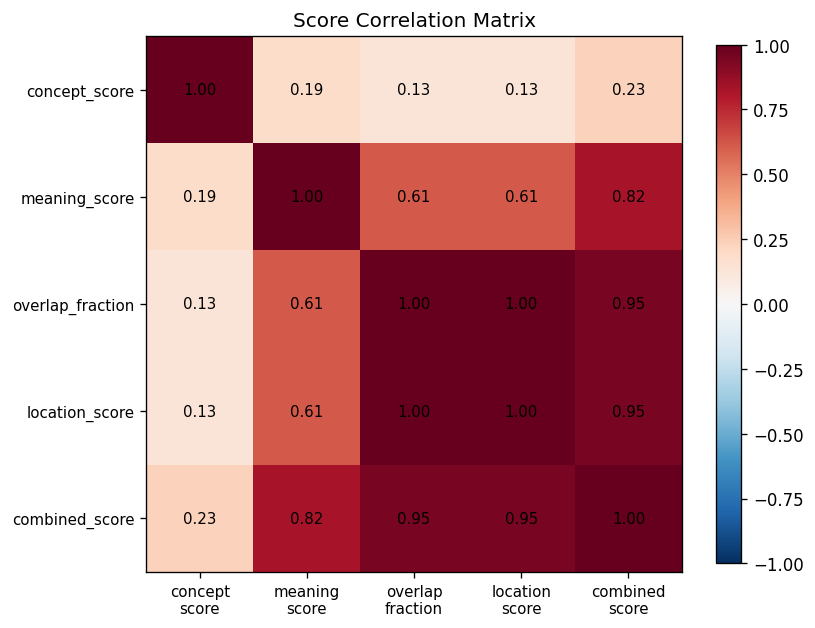

In [13]:
score_cols = ['concept_score', 'meaning_score', 'overlap_fraction', 'location_score', 'combined_score']
corr = df[score_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(score_cols)))
ax.set_yticks(range(len(score_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in score_cols], fontsize=9)
ax.set_yticklabels(score_cols, fontsize=9)
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Score Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Scatter: meaning_score vs overlap_fraction

High meaning but low overlap might indicate explanations that capture the concept but predict the wrong text location.

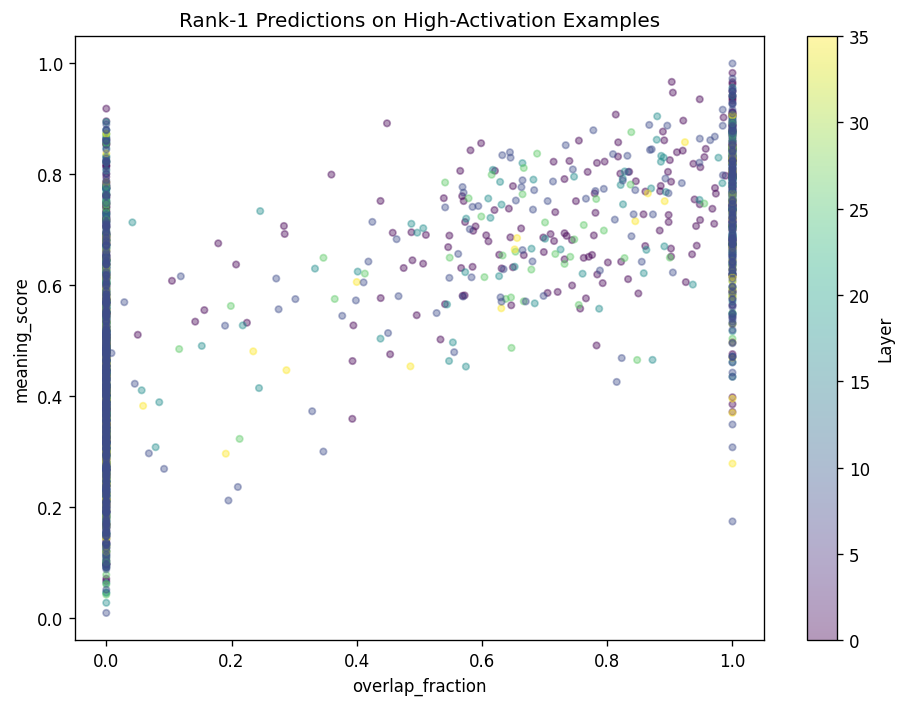

In [14]:
# Use rank-1 predictions for high-activation examples only
rank1_high = df[(df['prediction_rank'] == 1) & (df['normalized_activation'] > 0)]

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(rank1_high['overlap_fraction'], rank1_high['meaning_score'],
                     c=rank1_high['layer'], cmap='viridis', alpha=0.4, s=15)
ax.set_xlabel('overlap_fraction')
ax.set_ylabel('meaning_score')
ax.set_title('Rank-1 Predictions on High-Activation Examples')
fig.colorbar(scatter, ax=ax, label='Layer')
plt.tight_layout()
plt.show()

## 10. Explanation length vs quality

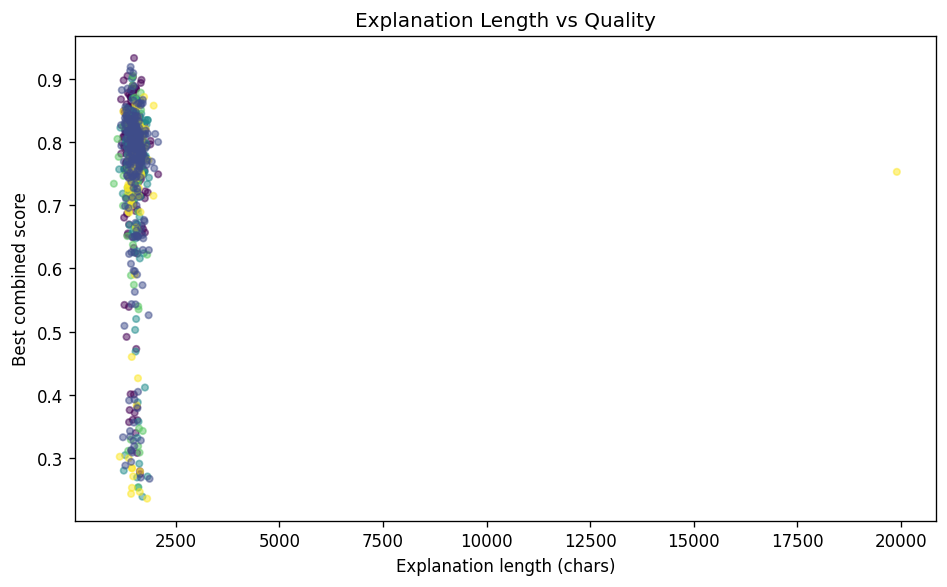

Correlation: -0.011


In [15]:
# Load full explanation lengths
expl_lengths = {}
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    with open(path) as f:
        data = json.load(f)
    expl_lengths[data['neuron_id']] = len(data.get('explanation_used', ''))

neuron_best['explanation_length'] = neuron_best['neuron_id'].map(expl_lengths)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(neuron_best['explanation_length'], neuron_best['best_combined'],
           c=neuron_best['layer'], cmap='viridis', alpha=0.5, s=15)
ax.set_xlabel('Explanation length (chars)')
ax.set_ylabel('Best combined score')
ax.set_title('Explanation Length vs Quality')
plt.tight_layout()
plt.show()

print(f"Correlation: {neuron_best['explanation_length'].corr(neuron_best['best_combined']):.3f}")

## 11. CSV analysis: substring prediction distances

In [16]:
csv_path = os.path.join(EXPL_DIR, 'explanation_scores.csv')
csv_df = pd.read_csv(csv_path)
print(f"CSV shape: {csv_df.shape}")
print(f"Columns: {list(csv_df.columns)}")
csv_df.head(3)

CSV shape: (70, 14)
Columns: ['Provided text', 'Provided text length (chars)', 'Provided text word count', 'Actual substring', 'Correct substring', 'Predicted substring 1', 'Predicted substring 2', 'Predicted substring 3', 'Closest substring to actual', 'Distance from best guess to actual (chars)', 'Average distance from correct substring (chars)', 'Signed distance 1 (chars)', 'Signed distance 2 (chars)', 'Signed distance 3 (chars)']


,Provided text,Provided text length (chars),Provided text word count,Actual substring,Correct substring,Predicted substring 1,Predicted substring 2,Predicted substring 3,Closest substring to actual,Distance from best guess to actual (chars),Average distance from correct substring (chars),Signed distance 1 (chars),Signed distance 2 (chars),Signed distance 3 (chars)
0,The Unlikely Fix to Crypto's Privacy Failures:...,8782,1379,to acknowledge we can’t just rely on technolog...,1.0,Maybe it’s time to acknowledge we can’t just r...,It’s a disincentive to hackers. It could off...,"Indeed, the biggest problem with all these bre...",Maybe it’s time to acknowledge we can’t just r...,16.0,1444.5,-16.0,2873.0,NaN
1,Lots happening this weekend in San Antonio. He...,2126,349,Also Saturday Councilwoman Rebecca Viagran on ...,NaN,Also Saturday Councilwoman Rebecca Viagran on ...,"'It's a traditional folk play, and we believe...",If you're wondering what this one-of-a-kind Ch...,NaN,NaN,NaN,NaN,NaN,NaN
2,How Chris Martin Really Felt About The Coldpla...,2650,449,nature of music is that it's an ongoing conver...,NaN,"Another wrote, 'it's disrespectful to complete...",'It's water moving. I think what you're doing...,'Some people are very protective of the origi...,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Clean up numeric columns
dist_col = 'Distance from best guess to actual (chars)'
avg_dist_col = 'Average distance from correct substring (chars)'

csv_numeric = csv_df[[dist_col, avg_dist_col, 'Provided text length (chars)',
                       'Provided text word count']].apply(pd.to_numeric, errors='coerce')

print("Substring prediction distance stats:")
csv_numeric.describe().round(1)

Substring prediction distance stats:


,Distance from best guess to actual (chars),Average distance from correct substring (chars),Provided text length (chars),Provided text word count
count,50.0,50.0,70.0,70.0
mean,422.2,945.6,3617.1,580.2
std,588.6,726.0,2149.3,351.1
min,0.0,0.0,426.0,66.0
25%,30.0,463.3,2009.8,319.0
50%,150.5,703.0,2920.5,462.0
75%,531.2,1381.4,5320.0,829.5
max,2231.0,2827.3,8782.0,1535.0


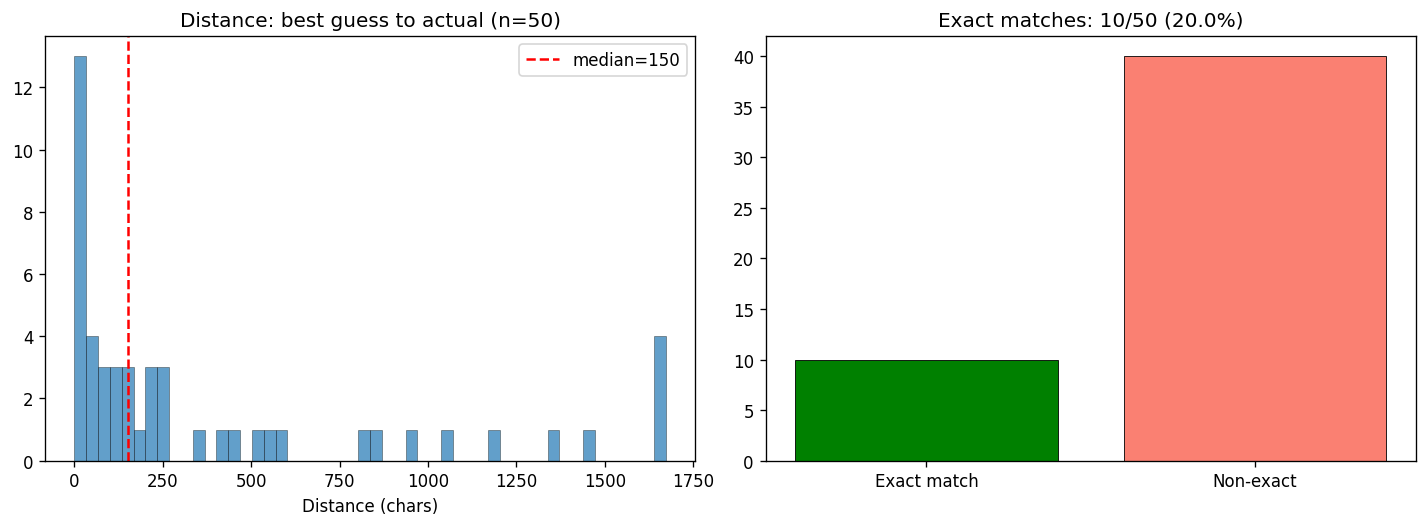

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

valid_dist = csv_numeric[dist_col].dropna()
if len(valid_dist) > 0:
    axes[0].hist(valid_dist.clip(upper=valid_dist.quantile(0.95)), bins=50, alpha=0.7,
                 edgecolor='black', linewidth=0.3)
    axes[0].set_title(f'Distance: best guess to actual (n={len(valid_dist)})')
    axes[0].set_xlabel('Distance (chars)')
    axes[0].axvline(valid_dist.median(), color='red', linestyle='--',
                    label=f'median={valid_dist.median():.0f}')
    axes[0].legend()

# Exact match rate
exact_matches = (valid_dist == 0).sum()
axes[1].bar(['Exact match', 'Non-exact'], [exact_matches, len(valid_dist) - exact_matches],
            color=['green', 'salmon'], edgecolor='black', linewidth=0.5)
axes[1].set_title(f'Exact matches: {exact_matches}/{len(valid_dist)} ({100*exact_matches/len(valid_dist):.1f}%)')

plt.tight_layout()
plt.show()

## 12. Summary statistics

In [19]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total neurons scored:      {neuron_best['neuron_id'].nunique()}")
print(f"Layers:                    {sorted(neuron_best['layer'].unique())}")
print(f"Neurons per layer:         {dict(neuron_best['layer'].value_counts().sort_index())}")
print()
print(f"Mean best_combined:        {neuron_best['best_combined'].mean():.3f}")
print(f"Median best_combined:      {neuron_best['best_combined'].median():.3f}")
print(f"Neurons with best >= 0.7:  {(neuron_best['best_combined'] >= 0.7).sum()} ({100*(neuron_best['best_combined'] >= 0.7).mean():.1f}%)")
print(f"Neurons with best >= 0.5:  {(neuron_best['best_combined'] >= 0.5).sum()} ({100*(neuron_best['best_combined'] >= 0.5).mean():.1f}%)")
print(f"Neurons with best < 0.2:   {(neuron_best['best_combined'] < 0.2).sum()} ({100*(neuron_best['best_combined'] < 0.2).mean():.1f}%)")

SUMMARY
Total neurons scored:      854
Layers:                    [np.int64(0), np.int64(8), np.int64(17), np.int64(26), np.int64(35)]
Neurons per layer:         {0: np.int64(233), 8: np.int64(257), 17: np.int64(178), 26: np.int64(97), 35: np.int64(89)}

Mean best_combined:        0.748
Median best_combined:      0.789
Neurons with best >= 0.7:  712 (83.4%)
Neurons with best >= 0.5:  790 (92.5%)
Neurons with best < 0.2:   0 (0.0%)


In [20]:
import json, os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

EXPL_DIR = 'explanations'

In [9]:
# Debug: find which unified_scores files aren't loading properly
import json, os, glob

EXPL_DIR = 'explanations'
loaded = set()
failed = []
empty_results = []

for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    try:
        with open(path) as f:
            data = json.load(f)
        nid = data.get('neuron_id', '')
        results = data.get('results', [])
        if not results:
            empty_results.append((nid, path))
        else:
            has_pairs = any(res.get('pairs') for res in results)
            if not has_pairs:
                empty_results.append((nid, path))
            else:
                loaded.add(nid)
    except Exception as e:
        failed.append((path, str(e)))

print(f"Successfully loaded with pairs: {len(loaded)}")
print(f"Empty results or no pairs: {len(empty_results)}")
print(f"Failed to parse: {len(failed)}")

if empty_results:
    print(f"\nFirst {len(empty_results)} empty/no-pairs files:")
    for nid, path in empty_results[:len(empty_results)]:
        print(nid)
        
if failed:
    print(f"\nFirst {len(empty_results)} empty/no-pairs files:")
    for path, err in failed[:len(empty_results)]:
        print(f"  {os.path.basename(path)}: {err}")

Successfully loaded with pairs: 854
Empty results or no pairs: 278
Failed to parse: 0

First 278 empty/no-pairs files:
0_10261
0_10280
0_10332
0_11624
0_11683
0_11748
0_12323
0_1243
0_13323
0_14035
0_14741
0_15120
0_15578
0_15685
0_16195
0_16235
0_16550
0_16743
0_16868
0_16869
0_17096
0_17160
0_1899
0_19040
0_19378
0_19606
0_19994
0_2042
0_2613
0_2795
0_2812
0_2870
0_3893
0_4111
0_4301
0_4341
0_4621
0_5714
0_6050
0_6118
0_6371
0_6473
0_6475
0_6547
0_6562
0_6726
0_6747
0_6865
0_6947
0_7032
0_7614
0_7625
0_7657
0_7721
0_7795
0_7868
0_801
0_8491
0_8695
0_8914
0_9098
0_9502
0_975
0_9840
0_9996
17_10185
17_10427
17_10835
17_11078
17_11413
17_1145
17_11890
17_12032
17_12271
17_12667
17_1316
17_13203
17_13698
17_136
17_13720
17_13966
17_14277
17_14410
17_14420
17_14656
17_15232
17_15622
17_15869
17_16209
17_1622
17_16310
17_16336
17_16369
17_16474
17_16641
17_16659
17_17262
17_1738
17_17443
17_17718
17_17774
17_18269
17_18474
17_19168
17_19283
17_19351
17_19585
17_19610
17_196
17_19884
17_200